# Исследовательский анализ "Яндекс Афиша"

## 1. Цели
> **Заполнить!**

## 2. Описание
> **Заполнить!**

## 3. Содержимое

- `user_id` — уникальный идентификатор пользователя, совершившего заказ;
- `device_type_canonical` — тип устройства, с которого был оформлен заказ (`mobile` — мобильные устройства, `desktop` — стационарные);
- `order_id` — уникальный идентификатор заказа;
- `order_dt` — дата создания заказа (используйте данные `created_dt_msk`);
- `order_ts` — дата и время создания заказа (используйте данные `created_ts_msk`);
- `currency_code` — валюта оплаты;
- `revenue` — выручка от заказа;
- `tickets_count` — количество купленных билетов;
- `days_since_prev` — количество дней от предыдущей покупки пользователя, для пользователей с одной покупкой — значение пропущено;
- `event_id` — уникальный идентификатор мероприятия;
- `service_name` — название билетного оператора;
- `event_type_main` — основной тип мероприятия (театральная постановка, концерт и так далее);
- `region_name` — название региона, в котором прошло мероприятие;
- `city_name` — название города, в котором прошло мероприятие.

## 4. Загрузка данных и их предобработка

### 4.1 Импорт библиотек

In [1]:
import marimo as mo
import pandas as pd
from phik import phik_matrix
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns


### 4.2 Выгружаем датафрейм из БД (1.1) (UC)

In [2]:
# Выгрузка из БД

import psycopg2  # библиотека для подключения к PostgreSQL
import os        # модуль для работы с переменными окружения
from dotenv import load_dotenv  # функция для загрузки переменных окружения из .env файла

# Загружаем переменные окружения из файла .env в текущую среду
# Это позволяет не хранить логины и пароли прямо в коде
load_dotenv()

# Устанавливаем соединение с базой данных PostgreSQL
# Параметры подключения берутся из переменных окружения:
# PGHOST — хост базы данных
# PGPORT — порт
# PGDATABASE — имя базы данных
# PGUSER — пользователь
# PGPASSWORD — пароль
conn = psycopg2.connect(
    host=os.getenv("PGHOST"),
    port=os.getenv("PGPORT"),
    dbname=os.getenv("PGDATABASE"),
    user=os.getenv("PGUSER"),
    password=os.getenv("PGPASSWORD"),
)

# Откатываем возможную незавершённую транзакцию
conn.rollback()


# Функция для загрузки SQL-запроса из файла
# path — путь к файлу .sql
# возвращает строку с SQL-запросом
def load_sql(path: str) -> str:
    with open(path, "r") as f:
        return f.read()


# Загружаем SQL-запрос из файла витрины данных
# В данном случае — витрина покупок пользователей Афиши
query = load_sql("sql/marts/afisha_purchases_mart.sql")


# Выполняем SQL-запрос и загружаем результат в pandas DataFrame,
# затем сохраняем результат в CSV файл
# datasets/dataset.csv — файл, который будет использоваться далее для анализа

#pd.read_sql(query, conn).to_csv('datasets/dataset.csv', index=False)


# Позже этот CSV можно загрузить обратно в DataFrame для анализа:
# df = pd.read_csv('datasets/dataset.csv')

### 4.3 Изучение общей информации о выгруженных данных (1.2)

In [3]:
df_original = pd.read_csv('datasets/dataset.csv')
df_raw = df_original.copy()

In [4]:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 290849 entries, 0 to 290848
Data columns (total 14 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   user_id                290849 non-null  str    
 1   device_type_canonical  290849 non-null  str    
 2   order_id               290849 non-null  int64  
 3   order_dt               290849 non-null  str    
 4   order_ts               290849 non-null  str    
 5   currency_code          290849 non-null  str    
 6   revenue                290849 non-null  float64
 7   tickets_count          290849 non-null  int64  
 8   days_since_prev        268909 non-null  float64
 9   event_id               290849 non-null  int64  
 10  event_type_main        290849 non-null  str    
 11  service_name           290849 non-null  str    
 12  region_name            290849 non-null  str    
 13  city_name              290849 non-null  str    
dtypes: float64(2), int64(3), str(9)
memory usage: 3

In [5]:
# Выведем данные с начала и с конца датафрейма
df_raw.head(), df_raw.tail()

(           user_id device_type_canonical  order_id    order_dt  \
 0  0002849b70a3ce2                mobile   4359165  2024-08-20   
 1  0005ca5e93f2cf4                mobile   7965605  2024-07-23   
 2  0005ca5e93f2cf4                mobile   7292370  2024-10-06   
 3  000898990054619                mobile   1139875  2024-07-13   
 4  000898990054619                mobile    972400  2024-10-04   
 
               order_ts currency_code  revenue  tickets_count  days_since_prev  \
 0  2024-08-20 16:08:03           rub  1521.94              4              NaN   
 1  2024-07-23 18:36:24           rub   289.45              2              NaN   
 2  2024-10-06 13:56:02           rub  1258.57              4             75.0   
 3  2024-07-13 19:40:48           rub     8.49              2              NaN   
 4  2024-10-04 22:33:15           rub  1390.41              3             83.0   
 
    event_id event_type_main        service_name           region_name  \
 0    169230           театр

In [6]:
# Функция тестирования датафрейма на валидность
def validate_dataset(df: pd.DataFrame) -> None:
    """
    Проверка корректности выгруженного датасета.
    Останавливает выполнение при обнаружении критических ошибок.
    """

    print("Запуск проверки датасета.")

    # Проверка, что датафрейм не пустой
    if df.empty:
        raise ValueError("Датасет пустой")
    print("Тест 1 пройден: датафрейм не пустой")

    # Проверка структуры (колонки)
    expected_columns = {
        'user_id',
        'device_type_canonical',
        'order_id',
        'order_dt',
        'order_ts',
        'currency_code',
        'revenue',
        'tickets_count',
        'days_since_prev',
        'event_id',
        'event_type_main',
        'service_name',
        'region_name',
        'city_name'
    }

    missing_columns = expected_columns - set(df.columns)

    if missing_columns:
        raise ValueError(f"Отсутствуют колонки: {missing_columns}")
    print("Тест 2 пройден: структура датафрейма корректна")

    # Проверка на дубликаты ключа
    duplicate_count = df['order_id'].duplicated().sum()

    if duplicate_count > 0:
        raise ValueError(f"Обнаружено {duplicate_count} дубликатов order_id")
    print("Тест 3 пройден: дубликаты order_id отсутствуют")

    # Проверка revenue
    if (df['revenue'] < 0).any():
        raise ValueError("Обнаружена отрицательная revenue")
    print("Тест 4 пройден: revenue не содержит отрицательных значений")

    # Проверка tickets_count
    if (df['tickets_count'] <= 0).any():
        raise ValueError("Обнаружен tickets_count <= 0")
    print("Тест 5 пройден: tickets_count > 0 для всех строк")

    # Проверка device_type
    valid_devices = {'mobile', 'desktop'}

    invalid_devices = set(df['device_type_canonical']) - valid_devices

    if invalid_devices:
        raise ValueError(f"Некорректные device_type: {invalid_devices}")
    print("Тест 6 пройден: device_type_canonical содержит только допустимые значения")

    # Проверка дат
    order_dt_parsed = pd.to_datetime(df['order_dt'], errors='coerce')
    order_ts_parsed = pd.to_datetime(df['order_ts'], errors='coerce')

    if order_dt_parsed.isna().any():
        raise ValueError("Некорректные значения в order_dt")
    print("Тест 7 пройден: order_dt корректно парсится в дату")

    if order_ts_parsed.isna().any():
        raise ValueError("Некорректные значения в order_ts")
    print("Тест 8 пройден: order_ts корректно парсится в datetime")

    # Проверка days_since_prev
    days_parsed = pd.to_numeric(df['days_since_prev'], errors='coerce')

    invalid_days = df['days_since_prev'].notna() & days_parsed.isna()

    if invalid_days.any():
        raise ValueError("Обнаружены некорректные значения в days_since_prev")
    print("Тест 9 пройден: days_since_prev содержит только числовые значения или NULL")

    print("Проверка датасета успешно пройдена.")

In [7]:
# Проверим датасет на валидность 1
#validate_dataset(df_raw)

In [8]:
# Обработка отрицательного revenue 
f'Доля отрицательных значений в поле revenue: {round(df_raw[df_raw['revenue'] < 0].shape[0] * 100 / df_raw.shape[0], 2)}%'

'Доля отрицательных значений в поле revenue: 0.13%'

Доля отрицательных значений в поле revenue `<5%` от общего объема и составляет `0.13%`. Следовательно, мы можем избавиться от аномальных записей.

In [9]:
#Находим индексы строк с отрицательным revenue
bad_idx = df_raw.index[df_raw["revenue"] < 0]

# Удаляем их из df + сбрасываем индекс
df_raw.drop(index=bad_idx, inplace=True)
df_raw.reset_index(drop=True, inplace=True)

In [10]:
# Проверим датасет на валидность 2
validate_dataset(df_raw)

Запуск проверки датасета.
Тест 1 пройден: датафрейм не пустой
Тест 2 пройден: структура датафрейма корректна
Тест 3 пройден: дубликаты order_id отсутствуют
Тест 4 пройден: revenue не содержит отрицательных значений
Тест 5 пройден: tickets_count > 0 для всех строк
Тест 6 пройден: device_type_canonical содержит только допустимые значения
Тест 7 пройден: order_dt корректно парсится в дату
Тест 8 пройден: order_ts корректно парсится в datetime
Тест 9 пройден: days_since_prev содержит только числовые значения или NULL
Проверка датасета успешно пройдена.


**Промежуточный вывод:**

1. **Объём и структура данных.**
Мы успешно загрузили датасет, который содержит 290 849 записей и 14 колонок (~31 mb). Структура данных соответствует ожидаемой, все необходимые признаки присутствуют. Типы данных корректны и позволяют проводить дальнейший анализ.

2. **Качество данных.**
В ходе первичного анализа мы обнаружили пропуски только в поле `days_since_prev`. Это ожидаемо, поскольку для пользователей с одной покупкой отсутствует предыдущая транзакция. Некорректных значений в полях `order_dt` и `order_ts` не выявлено — данные успешно приводятся к форматам даты и времени. Остальные ключевые признаки содержат допустимые значения.

3. **Аномалии и их обработка.**
Мы выявили небольшую долю отрицательных значений в поле `revenue` — 0.13% от общего объёма данных. Такие значения являются аномальными с точки зрения бизнес-логики, поэтому мы приняли решение удалить соответствующие записи. После удаления аномалий датасет успешно прошёл проверку валидности.

4. **Целостность и корректность данных.**
В процессе проверки мы убедились, что дубликаты по ключевому полю `order_id` отсутствуют. Также не выявлено критических ошибок, которые могли бы повлиять на результаты анализа. Все признаки находятся в корректном формате.

На этапе предобработки можно расширить признаковое пространство за счет декомпозиции временных признаков. Это позволит анализировать сезонность, активность по дням недели и по времени суток. А также можно оптимизировать типы данных для уменьшения объема памяти.

## 5. Предобработка данных

### 5.1 Обрабтка категориальных признаков

In [11]:
# Проверим event_type_main на некорректные значения
df_raw['event_type_main'].unique()

<StringArray>
['театр', 'выставки', 'другое', 'стендап', 'концерты', 'спорт', 'фильм',
 'ёлки']
Length: 8, dtype: str

In [12]:
# Проверим currency_code на некорректные значения
df_raw['currency_code'].unique()

<StringArray>
['rub', 'kzt']
Length: 2, dtype: str

In [13]:
# Проверим service_name на некорректные значения
df_raw['service_name'].unique()

<StringArray>
[          'Край билетов',              'Мой билет',            'За билетом!',
            'Лови билет!',     'Билеты без проблем',                'Облачко',
          'Лучшие билеты',              'Прачечная',            'Быстробилет',
           'Дом культуры',         'Весь в билетах',          'Билеты в руки',
            'Тебе билет!',            'Show_ticket', 'Городской дом культуры',
                 'Яблоко',      'Билет по телефону',         'Выступления.ру',
               'Росбилет',        'Шоу начинается!',               'Мир касс',
              'Восьмёрка',              'Телебилет',          'Crazy ticket!',
                 'Реестр',         'Быстрый кассир',             'КарандашРУ',
           'Радио ticket',                'Дырокол',                'Вперёд!',
             'Кино билет',           'Цвет и билет',               'Зе Бест!',
              'Тех билет',                 'Лимоны',     'Билеты в интернете']
Length: 36, dtype: str

### 5.2 Обработка временных признаков и расширение признакового пространства

In [14]:
# Приводим тип полей order_dt и order_ts к date и datetime 
df_raw['order_dt'] = pd.to_datetime(df_raw['order_dt'], errors='coerce').dt.date
df_raw['order_ts'] = pd.to_datetime(df_raw['order_ts'], errors='coerce')

In [15]:
# расширим признаковое пространство, за счет декомпозиции временных признаков
df_raw['order_year'] = df_raw['order_ts'].dt.year.astype('int16')
df_raw['order_month'] = df_raw['order_ts'].dt.month.astype('int8')
df_raw['order_day'] = df_raw['order_ts'].dt.day.astype('int8')
df_raw['order_weekday'] = df_raw['order_ts'].dt.weekday.astype('int8')
df_raw['order_hour'] = df_raw['order_ts'].dt.hour.astype('int8')

### 5.3 Приведение выручки к единой валюте (2.1)

In [16]:
# Загружаем датасет с курсом тенге
tenge_rate_df = pd.read_csv('datasets/final_tickets_tenge_df.csv'
)

# Посмотрим структуру
tenge_rate_df.head(), tenge_rate_df['cdx'].unique(), tenge_rate_df['nominal'].unique()

(         data  nominal     curs  cdx
 0  2024-01-10      100  19.9391  kzt
 1  2024-01-11      100  19.7255  kzt
 2  2024-01-12      100  19.5839  kzt
 3  2024-01-13      100  19.4501  kzt
 4  2024-01-14      100  19.4501  kzt,
 <StringArray>
 ['kzt']
 Length: 1, dtype: str,
 array([100]))

In [17]:
# Рассчитываем курс: сколько рублей за 1 тенге
tenge_rate_df['kzt_to_rub'] = tenge_rate_df['curs'] / tenge_rate_df['nominal']

# Приводим дату к формату date для корректного merge
tenge_rate_df['order_dt'] = pd.to_datetime(tenge_rate_df['data']).dt.date

# Добавляем курс в основной датафрейм
df = df_raw.merge(tenge_rate_df[['order_dt', 'kzt_to_rub']], 
                          on='order_dt', 
                          how='left')

In [18]:
# Создаем новый столбец revenue_rub
# если валюта kzt — конвертируем через курс, иначе не меняем
df['revenue_rub'] = df['revenue']

mask_kzt = df['currency_code'] == 'kzt'
df.loc[mask_kzt, 'revenue_rub'] = (
    df.loc[mask_kzt, 'revenue'] * df.loc[mask_kzt, 'kzt_to_rub']
)

# Удаляем вспомогательный столбец курса
df.drop(columns=['kzt_to_rub'], inplace=True)

In [19]:
# Проверим результат 
df[df['currency_code'] =='kzt'].head(), df[df['currency_code'] =='rub'].head()

(             user_id device_type_canonical  order_id    order_dt  \
 73   0033403583a55ed                mobile   7850214  2024-09-17   
 92   0040e12d70fae81               desktop   8634925  2024-09-02   
 99   0054b38b2653e6e                mobile   7625522  2024-09-09   
 288  00f4f5244501ce6                mobile    720419  2024-06-11   
 471  01370a0e9c1a7d5                mobile   2229782  2024-06-04   
 
                order_ts currency_code   revenue  tickets_count  \
 73  2024-09-17 16:52:06           kzt    518.10              4   
 92  2024-09-02 19:49:14           kzt    347.18              3   
 99  2024-09-09 18:06:04           kzt    328.77              4   
 288 2024-06-11 20:15:57           kzt  22021.55              5   
 471 2024-06-04 13:17:35           kzt   3698.83              2   
 
      days_since_prev  event_id event_type_main        service_name  \
 73              20.0    559919          другое  Билеты без проблем   
 92              39.0    559476       

### 5.4 Обработка числовых признаков

In [20]:
# Проверим статистические показатели полей, что понять, можно ли их сжать
fields = ['tickets_count', 'days_since_prev', 'event_id', 'order_id', 'revenue_rub']
df[fields].describe()

,tickets_count,days_since_prev,event_id,order_id,revenue_rub
count,290468.000000,268560.000000,290468.000000,2.904680e+05,290468.000000
mean,2.755068,3.223928,438013.026461,4.326735e+06,555.859389
std,1.170481,11.359094,147429.224947,2.497659e+06,875.618843
min,1.000000,0.000000,4436.000000,1.000000e+00,-0.000000
25%,2.000000,0.000000,361772.000000,2.163539e+06,114.137500
50%,3.000000,0.000000,498282.000000,4.328150e+06,351.615652
75%,4.000000,1.000000,546282.500000,6.488381e+06,802.250000
max,57.000000,148.000000,592325.000000,8.653108e+06,81174.540000


В полях `tickets_count`, `days_since_prev` и `revenue_rub` обнаружены критические выбросы. Мы избавимся от них, используя 99-й процентиль.

In [21]:
# На основе стат. показателей выберем подходящие типы для полей
df['days_since_prev'] = df['days_since_prev'].astype('float32')
df['tickets_count'] = df['tickets_count'].astype('uint8')
df[['event_id', 'order_id']] = df[['event_id', 'order_id']].astype('int32')

# Приведение финансовых показателей
df[['revenue', 'revenue_rub']] = df[['revenue', 'revenue_rub']].astype('float32')

Отметим, что поля `revenue` и `revenue_rub` не следует сжимать, так как они являются финансовыми показателями, и потеря точности может быть критичной для корректности денежных агрегатов. Однако для аналитических расчётов допустимо приведение к типу `float32`.

In [22]:
# Избавляемся от выбросов по 99 процентилю
outliers_idx = df.index[(df["tickets_count"] > df['tickets_count'].quantile(0.99))
                      | (df["days_since_prev"] > df['days_since_prev'].quantile(0.99))
                      | (df["revenue_rub"] > df['revenue_rub'].quantile(0.99))]

print(f'Суммарная доля выбросов в полях day_since_prev, revenue_rub и tickets_count: {round(len(outliers_idx) * 100 / df.shape[0], 2)}%')

Суммарная доля выбросов в полях day_since_prev, revenue_rub и tickets_count: 1.94%


Суммарная доля выбросов и, ранее удаленных, аномальных зачений не превышает 5%. Можем избавиться от выбросов.

In [23]:
# Удаляем их из df + сбрасываем индекс
df.drop(index=outliers_idx, inplace=True)
df.reset_index(drop=True, inplace=True)

print(f"Размер df после удаления выбросов: {df.shape}")

Размер df после удаления выбросов: (284846, 20)


### 5.5 Нормализация, обработка явных и неявных дубликатов

In [24]:
# Функция нормализации текстовых полей
def normalize_text_column(series: pd.Series) -> pd.Series:
    """
    Нормализует строковое поле:
    - приводит к строковому типу
    - убирает лишние пробелы
    - приводит к нижнему регистру
    - заменяет множественные пробелы на один
    - убирает пробелы в начале и конце
    """
    return (
        series
        .astype("string")
        .str.strip()
        .str.lower()
        .str.replace(r"\s+", " ", regex=True)
    )

In [25]:
# Применяем нормализацию к нужным полям
columns_to_normalize = ['service_name', 'region_name', 'city_name']

for col in columns_to_normalize:
    df[col] = normalize_text_column(df[col])

In [26]:
# Проверим на явные дубликаты
explicit_duplicates = df.duplicated()

print(f"Количество явных дубликатов: {explicit_duplicates.sum()}")
print(f"Доля явных дубликатов: {round(explicit_duplicates.mean() * 100, 2)}%")

Количество явных дубликатов: 0
Доля явных дубликатов: 0.0%


In [27]:
# Проверим на неявные дубликаты по ключевому бизнес-идентификатору order_id
implicit_duplicates_order = df.duplicated(subset=['order_id'])

print(f"Количество неявных дубликатов по order_id: {implicit_duplicates_order.sum()}")
print(f"Доля неявных дубликатов по order_id: {round(implicit_duplicates_order.mean() * 100, 2)}%")

Количество неявных дубликатов по order_id: 0
Доля неявных дубликатов по order_id: 0.0%


In [28]:
# Проверим на неявные дубликаты заказов одного пользователя в один момент времени
implicit_duplicates_user_time = df.duplicated(
    subset=['user_id', 'order_ts', 'event_id', 'service_name']
)

print(f"Количество потенциальных дублей заказов: {implicit_duplicates_user_time.sum()}")
print(f"Доля потенциальных дублей заказов: {round(implicit_duplicates_user_time.mean() * 100, 3)}%")

df[implicit_duplicates_user_time].head()

Количество потенциальных дублей заказов: 117
Доля потенциальных дублей заказов: 0.041%


,user_id,device_type_canonical,order_id,order_dt,order_ts,currency_code,revenue,tickets_count,days_since_prev,event_id,event_type_main,service_name,region_name,city_name,order_year,order_month,order_day,order_weekday,order_hour,revenue_rub
4315,02ea4583333f064,mobile,1158696,2024-08-23,2024-08-23 22:46:05,rub,59.740002,2,0.0,540072,другое,билеты в руки,зеленоградский округ,шаныртау,2024,8,23,4,22,59.740002
11595,06eb7897f65b433,mobile,1123983,2024-08-13,2024-08-13 16:31:07,rub,69.820000,1,0.0,183706,театр,билеты в руки,светополянский округ,глиноград,2024,8,13,1,16,69.820000
12491,08199117318954f,mobile,5593202,2024-07-31,2024-07-31 11:52:06,rub,0.000000,3,0.0,553623,другое,билеты без проблем,каменевский регион,глиногорск,2024,7,31,2,11,0.000000
13803,0ae42a8c1d07049,mobile,2534659,2024-09-02,2024-09-02 13:14:47,rub,47.590000,2,0.0,561445,спорт,билеты без проблем,чистогорская область,леснойск,2024,9,2,0,13,47.590000
15887,0beb8fc0c0a9ce1,mobile,1294329,2024-07-05,2024-07-05 11:18:59,rub,87.989998,1,0.0,496111,театр,прачечная,каменевский регион,глиногорск,2024,7,5,4,11,87.989998


In [29]:
# Удаляем найденные неявные дубликаты
df.drop_duplicates(
    subset=['user_id', 'order_ts', 'event_id', 'service_name'],
    keep='first',  # оставляем первый (предположительно оригинальный) заказ
    inplace=True
)

df.reset_index(drop=True, inplace=True)

In [30]:
# Проверим, что дубликаты удалены
implicit_duplicates_user_time_after = df.duplicated(
    subset=['user_id', 'order_ts', 'event_id', 'service_name']
)

print(f"Количество дублей после удаления: {implicit_duplicates_user_time_after.sum()}")
print(f"Размер df после удаления дублей: {df.shape}")

Количество дублей после удаления: 0
Размер df после удаления дублей: (284729, 20)


### 5.6 Промежуточный вывод по предобработке

В ходе предобработки данных мы последовательно привели датасет к состоянию, пригодному для дальнейшего исследовательского анализа.

Мы обработали категориальные признаки: устранили различия в регистре, лишние пробелы и неоднородности написания**.

Расширили временные признаки на основе исходного timestamp заказа. Были выделены **год, месяц, день, день недели и час заказа**. Это позволило подготовить данные для анализа **сезонности, поведенческих паттернов пользователей и временных закономерностей спроса**.

Также мы привели выручку к единой валюте и сформировали показатель **`revenue_rub`**, что устранило проблему несопоставимости денежных значений.

В числовых признаках мы провели **анализ выбросов**. Суммарная доля выбросов в полях **`days_since_prev`, `revenue_rub` и `tickets_count` составила 1.94%`**. Это небольшая доля наблюдений, поэтому их удаление **не оказывает существенного влияния на репрезентативность выборки**, но при этом позволяет **снизить влияние аномальных значений на статистики**. После удаления выбросов размер датасета составил **284 846 наблюдений**.

Выполнили **нормализацию текстовых признаков**, приведя их к единому формату.

Проверка на **явные дубликаты показала их отсутствие (0 наблюдений)**. Также мы проверили дубликаты по бизнес-ключу **`order_id`** и убедились, что **каждая запись имеет уникальный идентификатор заказа**.

Дополнительно мы выявили **потенциальные неявные дубликаты** — случаи, когда у одного пользователя зафиксирован заказ с одинаковыми **`order_ts`, `event_id` и `service_name`**. Было обнаружено **117 записей (0.041% выборки)**. С высокой вероятностью это **технические дубликаты**, поэтому мы удалили их, сохранив первое вхождение. После этого финальный размер датасета составил **284 729 наблюдений**, и повторная проверка подтвердила **полное отсутствие дубликатов**.

В результате мы получили **чистый и согласованный датасет**, в котором **устранены ключевые проблемы качества данных**, способные исказить результаты исследования.

## 6. Создание профиля пользователя

### 6.1 Профиль пользователя

In [31]:
# Сортируем по времени заказа
df_sorted = df.sort_values(['user_id', 'order_ts']).reset_index(drop=True)

# Профиль пользователя: первый заказ (берём строки с минимальным order_ts на пользователя)
first_orders = (
    df_sorted
    .groupby('user_id', as_index=False)
    .first()
    .rename(columns={
        'order_dt': 'first_order_dt',
        'order_ts': 'first_order_ts',
        'device_type_canonical': 'first_device',
        'region_name': 'first_region',
        'service_name': 'first_service_name',
        'event_type_main': 'first_event_type_main'
    })
)[[
    'user_id',
    'first_order_dt',
    'first_order_ts',
    'first_device',
    'first_region',
    'first_service_name',
    'first_event_type_main'
]]

# Агрегаты по пользователю
user_agg = (
    df_sorted.groupby('user_id', as_index=False)
    .agg(
        last_order_dt=('order_dt', 'max'),
        last_order_ts=('order_ts', 'max'),
        total_orders=('order_id', 'nunique'),
        avg_revenue_rub=('revenue_rub', 'mean'),
        avg_tickets_count=('tickets_count', 'mean'),
        # среднее время между заказами: days_since_prev числовое для повторных
        # берём среднее по доступным значениям
        avg_days_between=('days_since_prev', 'mean'),
    )
)

# Итоговый профиль
user_profile = (
    first_orders.merge(user_agg, on='user_id', how='left')
)

# Бинарные признаки
user_profile['is_two'] = (user_profile['total_orders'] >= 2).astype('uint8')
user_profile['is_five'] = (user_profile['total_orders'] >= 5).astype('uint8')

user_profile

,user_id,first_order_dt,first_order_ts,first_device,first_region,first_service_name,first_event_type_main,last_order_dt,last_order_ts,total_orders,avg_revenue_rub,avg_tickets_count,avg_days_between,is_two,is_five
0,0002849b70a3ce2,2024-08-20,2024-08-20 16:08:03,mobile,каменевский регион,край билетов,театр,2024-08-20,2024-08-20 16:08:03,1,1521.939941,4.000000,NaN,0,0
1,0005ca5e93f2cf4,2024-07-23,2024-07-23 18:36:24,mobile,каменевский регион,мой билет,выставки,2024-07-23,2024-07-23 18:36:24,1,289.450012,2.000000,NaN,0,0
2,000898990054619,2024-07-13,2024-07-13 19:40:48,mobile,североярская область,лови билет!,другое,2024-10-23,2024-10-23 15:12:00,2,455.614990,2.500000,19.000,1,0
3,00096d1f542ab2b,2024-08-15,2024-08-15 16:48:48,desktop,каменевский регион,край билетов,театр,2024-08-15,2024-08-15 16:48:48,1,917.830017,4.000000,NaN,0,0
4,000a55a418c128c,2024-09-29,2024-09-29 19:39:12,mobile,поленовский край,лучшие билеты,театр,2024-10-15,2024-10-15 10:29:04,2,61.309998,1.500000,16.000,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21827,fff13b79bd47d7c,2024-07-16,2024-07-16 22:17:10,mobile,каменевский регион,мой билет,другое,2024-10-31,2024-10-31 18:31:52,9,688.043335,2.555556,13.375,1,1
21828,fff32fc9ad0f9f6,2024-08-15,2024-08-15 14:36:28,desktop,каменевский регион,билеты без проблем,стендап,2024-08-15,2024-08-15 14:36:28,1,779.989990,3.000000,NaN,0,0
21829,fffcd3dde79eb2c,2024-06-20,2024-06-20 19:57:25,desktop,каменевский регион,билеты без проблем,концерты,2024-10-30,2024-10-30 13:37:43,33,557.908508,2.787879,4.125,1,1
21830,fffeeb3c120cf0b,2024-09-24,2024-09-24 10:07:42,desktop,широковская область,билеты без проблем,стендап,2024-09-24,2024-09-24 10:07:42,1,661.530029,2.000000,NaN,0,0


### 6.2 Проверка репрезентативности, базовые метрики и поиск аномалий

In [32]:
# Посчитаем статистические значения

# Считаем общее число пользователей
total_users = user_profile.shape[0]

# Считаем среднюю выручку с одного заказа
avg_revenue_per_order = (df['revenue_rub'].sum() / df['order_id'].nunique())

# Считаем доли пользователе с 2+ и 5+ заказами
share_is_two = user_profile['is_two'].mean()
share_is_five = user_profile['is_five'].mean()

# Определим поля для посчета describe()
cols = ['total_orders', 'avg_tickets_count', 'avg_days_between']

In [33]:
print(f'Общее число пользователей: {total_users}')
print(f'Средняя выручка с одного заказа (по профилям): {avg_revenue_per_order:.2f} руб.')
print(f'Доля пользователей с 2+ заказами: {share_is_two:.2%}')
print(f'Доля пользователей с 5+ заказами: {share_is_five:.2%}')
user_profile[cols].describe(percentiles=[.5, .9, .95, .99])

Общее число пользователей: 21832
Средняя выручка с одного заказа (по профилям): 517.84 руб.
Доля пользователей с 2+ заказами: 59.12%
Доля пользователей с 5+ заказами: 27.77%


,total_orders,avg_tickets_count,avg_days_between
count,21832.000000,21832.000000,12943.000000
mean,13.041819,2.737947,8.923632
std,121.527995,0.915930,11.426562
min,1.000000,1.000000,0.000000
50%,2.000000,2.750000,5.000000
90%,15.000000,4.000000,24.000000
95%,31.000000,4.000000,32.650002
99%,151.690000,5.000000,53.790001
max,10161.000000,6.000000,63.000000


In [34]:
# Проверка потенциальных аномалий
q_orders_99 = user_profile['total_orders'].quantile(0.99)
q_tickets_99 = user_profile['avg_tickets_count'].quantile(0.99)

print(f'99-й перцентиль total_orders: {q_orders_99}')
print(f'99-й перцентиль avg_tickets_count: {q_tickets_99}')

anom_orders = user_profile[user_profile['total_orders'] > q_orders_99]
anom_tickets = user_profile[user_profile['avg_tickets_count'] > q_tickets_99]

print(f'\nПользователей выше 99p по total_orders: {len(anom_orders)} ({len(anom_orders)/len(user_profile):.2%})')
print(f'Пользователей выше 99p по avg_tickets_count: {len(anom_tickets)} ({len(anom_tickets)/len(user_profile):.2%})')

99-й перцентиль total_orders: 151.6899999999987
99-й перцентиль avg_tickets_count: 5.0

Пользователей выше 99p по total_orders: 219 (1.00%)
Пользователей выше 99p по avg_tickets_count: 185 (0.85%)


In [35]:
# Отфильтруем выбросы
user_profile_filt = user_profile[
    (user_profile['total_orders'] <= q_orders_99) &
    (user_profile['avg_tickets_count'] <= q_tickets_99)
]

# Считаем долю отфильтрованных значений
filtered_share = 1 - (len(user_profile_filt) / len(user_profile))

# Пересчитаем статистические значения
total_users_filt = user_profile_filt.shape[0]
share_is_two_filt = user_profile_filt['is_two'].mean()
share_is_five_filt = user_profile_filt['is_five'].mean()

In [36]:
print(f'Общее число пользователей: {total_users_filt}')
print(f'Доля пользователей с 2+ заказами: {share_is_two_filt:.2%}')
print(f'Доля пользователей с 5+ заказами: {share_is_five_filt:.2%}')
print(f'Доля отфильтрованных значений: {filtered_share:.2%}')
user_profile_filt[cols].describe(percentiles=[.5, .9, .95, .99])

Общее число пользователей: 21428
Доля пользователей с 2+ заказами: 58.96%
Доля пользователей с 5+ заказами: 27.23%
Доля отфильтрованных значений: 1.85%


,total_orders,avg_tickets_count,avg_days_between
count,21428.000000,21428.000000,12668.000000
mean,6.397657,2.711188,9.097072
std,14.274745,0.876963,11.479214
min,1.000000,1.000000,0.000000
50%,2.000000,2.750000,5.285714
90%,14.000000,4.000000,24.000000
95%,26.000000,4.000000,33.000000
99%,79.730000,5.000000,54.000000
max,151.000000,5.000000,63.000000


### 6.3 Промежуточный вывод по профилю пользователей

На данном этапе мы сформировали профиль для **21 832 пользователей**, включающий **15 признаков**, отражающих первое взаимодействие пользователя (дата заказа, устройство, регион, сервис, тип мероприятия), а также агрегированные поведенческие характеристики: дату последнего заказа, общее число заказов, среднюю выручку, среднее число билетов и средний интервал между покупками. Дополнительно мы добавили бинарные признаки активности `is_two` и `is_five`.

У нас получилось, что средняя выручка с одного заказа составляет **517.84 руб.** Доля пользователей с повторными покупками (2+ заказа) составила **59.12%**, а доля активных пользователей (5+ заказов) — **27.77%**, что указывает на достаточно высокий уровень вовлечённости аудитории.

В ходе анализа распределений мы выявили наличие выбросов. Максимальное число заказов на пользователя составило **10 161** при медиане **2 заказа**, а 99-й перцентиль — **151 заказ**. По среднему числу билетов 99-й перцентиль составил **5 билетов** при максимуме **6 билетов**. При этом доля пользователей выше 99-го перцентиля составила **1.00% по числу заказов** и **0.85% по количеству билетов**.

В связи с этим мы выполнили фильтрацию выбросов по 99-му перцентилю. В результате мы удалили **1.85% пользователей**, и итоговый размер выборки составил **21 428 пользователей**. После фильтрации среднее число заказов снизилось с **13.04 до 6.4**, при этом медиана осталась равной **2 заказам**, что показывает, что нам удалось устранить влияние экстремальных значений без потери репрезентативности данных.

Таким образом, у нас получился репрезентативный профиль пользователей, который можно использовать для дальнейшего исследовательского анализа.

## 7. Исследовательский анализ

### 7.1. Исследование признаков первого заказа и их связи с возвращением на платформу
Исследуем признаки, описывающие первый заказ пользователя, и выясним, влияют ли они на вероятность возвращения пользователя.

#### 7.1.1. Изучим распределение пользователей по признакам.
- Сгруппируем пользователей:
    - по типу их первого мероприятия;
    - по типу устройства, с которого совершена первая покупка;
    - по региону проведения мероприятия из первого заказа;
    - по билетному оператору, продавшему билеты на первый заказ.
- Подсчитаем общее количество пользователей в каждом сегменте и их долю в разрезе каждого признака.

In [37]:
# Соглашение

# Предыдущая часть проекта (предобработка и формирование профиля пользователя) выполнена в marimo

# Текущая и последующие части будут выполнены в Jupyter Notebook

# Дальнейшая работа проводится с профилем пользователей — вводим сокращение:

up = user_profile_filt

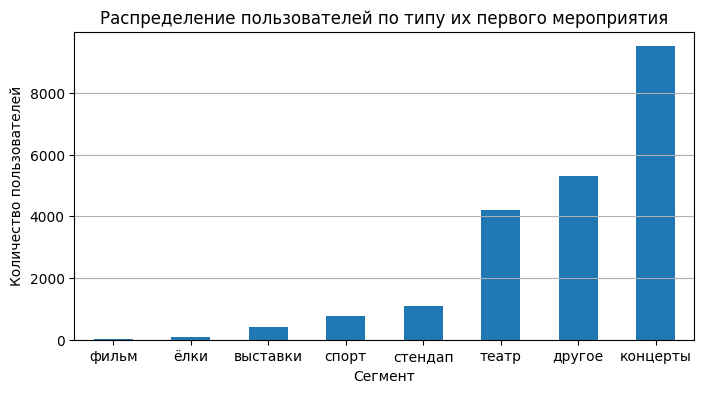

,first_event_type_main,users_count,share_pct
7,концерты,9506,44.36
6,другое,5312,24.79
5,театр,4207,19.63
4,стендап,1093,5.10
3,спорт,779,3.64
2,выставки,410,1.91
1,ёлки,94,0.44
0,фильм,27,0.13


In [38]:
# Распределение пользователей по типу их первого мероприятия
draft = up.groupby('first_event_type_main')['user_id'].count()
draft = draft.sort_values()

# Рисуем график
draft.plot(
    kind='bar', 
    title='Распределение пользователей по типу их первого мероприятия', 
    ylabel='Количество пользователей', 
    xlabel='Сегмент', 
    figsize=(8, 4), 
    rot=0
)
plt.grid(axis='y')
plt.show()

# Формируем таблицу с числовыми показателями
draft_df = draft.reset_index(name='users_count')
# Добавляем поле с долей в разрезе каждого признака
draft_df['share_pct'] = (draft_df['users_count'] / draft_df['users_count'].sum() * 100).round(2)
# Выводим таблицу в отсортированном формате
draft_df.sort_values(by='share_pct', ascending=False)

**Комментарий:**
Пользователи распределены неравномерно. Явной "точкой входа" можно считать "Концерты": **44.36%** пользователей выбрали их в качестве первого мероприятия. Также выделяются категории "Другое" (**24.79%**) и "Театр" (**19.63%**). Остальные категории занимают менее **15%** каждая, что указывает на их сравнительно низкую представленность в выборке.

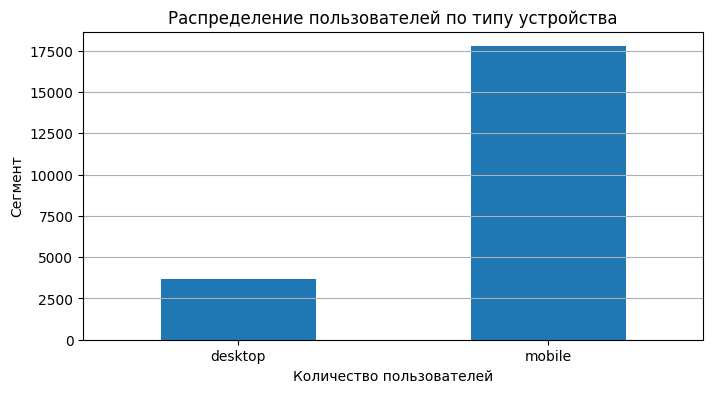

,first_device,users_count,share_pct
1,mobile,17758,82.87
0,desktop,3670,17.13


In [39]:
# Распределение пользователей по типу устройства с кот. была совершена первая покупка
draft = up.groupby('first_device')['user_id'].count()
draft = draft.sort_values()

# Рисуем график
draft.plot(
    kind='bar', 
    title='Распределение пользователей по типу устройства', 
    xlabel='Количество пользователей', 
    ylabel='Сегмент', 
    figsize=(8, 4), 
    rot=0
)
plt.grid(axis='y')
plt.show()

# Формируем таблицу с числовыми показателями
draft_df = draft.reset_index(name='users_count')
# Добавляем поле с долей в разрезе каждого признака
draft_df['share_pct'] = (draft_df['users_count'] / draft_df['users_count'].sum() * 100).round(2)
# Выводим таблицу в отсортированном формате
draft_df.sort_values(by='share_pct', ascending=False)

**Комментарий:**
(**82.87%**) пользователей оформили свой первый заказ с "Мобильного устройства". Подавляющее большинство пользователей использовали именно “Мобильное устройство”, поэтому в дальнейшем будем ориентироваться на эту категорию. 

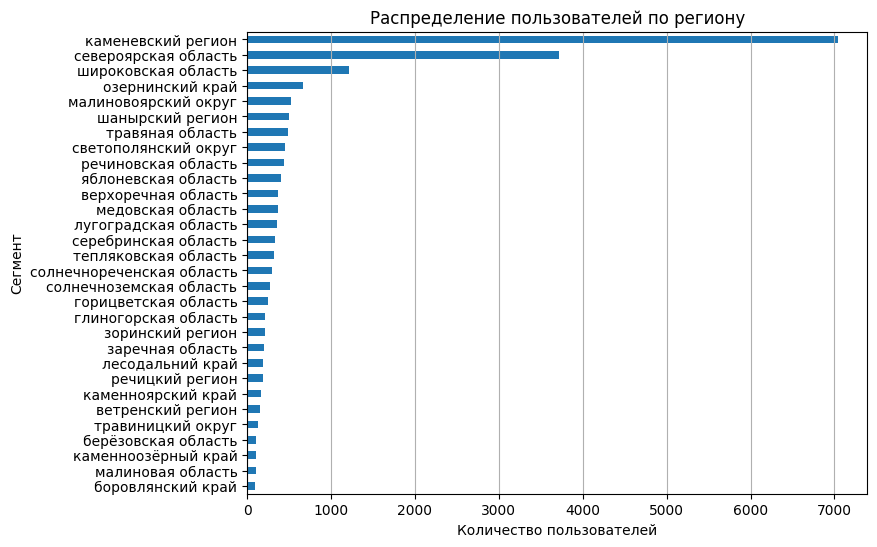

,first_region,users_count,share_pct
80,каменевский регион,7038,32.84
79,североярская область,3720,17.36
78,широковская область,1211,5.65
77,озернинский край,671,3.13
76,малиновоярский округ,521,2.43
...,...,...,...
8,крутоводский регион,3,0.01
9,верховинская область,3,0.01
2,верхозёрский край,1,0.00
1,сосноводолинская область,1,0.00


In [40]:
# Распределение пользователей по региону проведения мероприятия из первого заказа
draft = up.groupby('first_region')['user_id'].count()
draft = draft.sort_values()

# Заранее расчитаем доли
draft_df = draft.reset_index(name='users_count')
draft_df['share_pct'] = (draft_df['users_count'] / draft_df['users_count'].sum() * 100).round(2)

# Возьмем топ-30 регионов по количеству пользователей
draft = draft.tail(30)

# Рисуем график
draft.plot(
    kind='barh', 
    title='Распределение пользователей по региону', 
    xlabel='Количество пользователей', 
    ylabel='Сегмент', 
    figsize=(8, 6), 
    rot=0
)
plt.grid(axis='x')
plt.show()

# Выводим таблицу в отсортированном формате
draft_df.sort_values(by='share_pct', ascending=False)

**Комментарий:**
В данных представлено большое количество различных регионов, поэтому мы рассматриваем топ-30 наиболее активных. Явно выделяются "Каменевский регион" (**32.84%**) и "Североярская область" (**17.36%**) — их можно считать основными "Точками входа". Остальная часть распределения представлена большим количеством регионов с низкой долей и слабой дифференциацией (от **5.65%** до **0.00%**), что указывает на высокий уровень фрагментации аудитории по регионам.

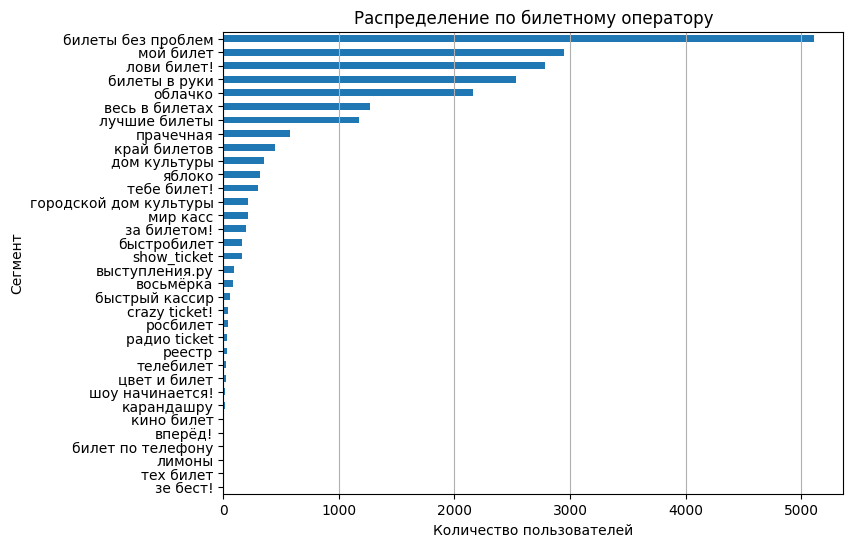

,first_service_name,users_count,share_pct
33,билеты без проблем,5108,23.84
32,мой билет,2950,13.77
31,лови билет!,2785,13.00
30,билеты в руки,2532,11.82
29,облачко,2164,10.10
28,весь в билетах,1272,5.94
27,лучшие билеты,1175,5.48
26,прачечная,578,2.70
25,край билетов,450,2.10
24,дом культуры,352,1.64


In [41]:
# Распределение по билетному оператору, продавшему билеты на первый заказ.
draft = up.groupby('first_service_name')['user_id'].count()
draft = draft.sort_values()

# Рисуем график
draft.plot(
    kind='barh', 
    title='Распределение по билетному оператору', 
    xlabel='Количество пользователей', 
    ylabel='Сегмент', 
    figsize=(8, 6), 
    rot=0
)
plt.grid(axis='x')
plt.show()

# Формируем таблицу с числовыми показателями
draft_df = draft.reset_index(name='users_count')
# Добавляем поле с долей в разрезе каждого признака
draft_df['share_pct'] = (draft_df['users_count'] / draft_df['users_count'].sum() * 100).round(2)
# Выводим таблицу в отсортированном формате
draft_df.sort_values(by='share_pct', ascending=False)

**Комментарий:** Также, как и в случае с регионами, выделяется "костяк" операторов-лидеров — топ-6. На них приходится около (**72.53%**) всех "первых" купленных билетов. Среди "топов" выделяется лидер — "Билеты без проблем" (**23.84%**), что составляет почти четверть всего рынка. Вероятнее всего, у этих операторов выстроена более эффективная рекламная кампания.

**Промежуточный вывод:**

> Вставить

#### 7.1.2. Проанализируем возвраты пользователей:
- Для каждого сегмента вычислим долю пользователей, совершивших два и более заказа.
- Визуализируем результат подходящим графиком.

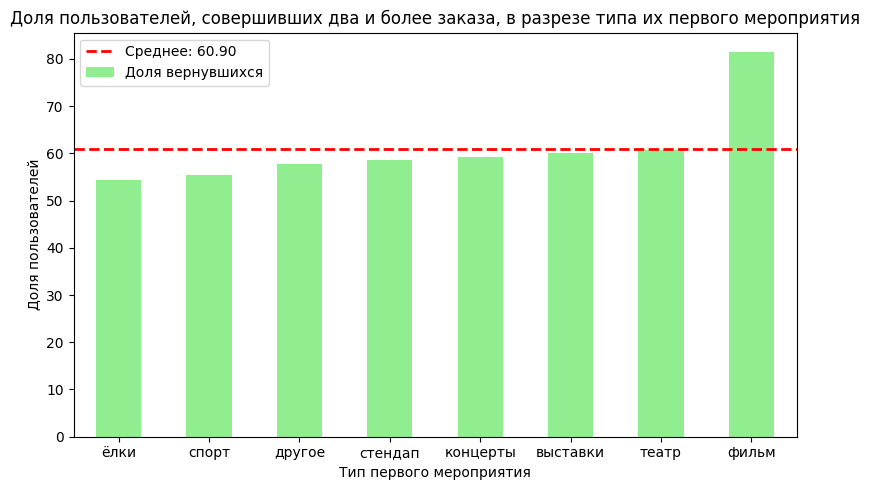

,first_event_type_main,count,return_rate_pct
7,ёлки,94,54.26
3,спорт,779,55.33
1,другое,5312,57.70
4,стендап,1093,58.55
2,концерты,9506,59.15
0,выставки,410,60.00
5,театр,4207,60.76
6,фильм,27,81.48


In [42]:
# Доля пользователей, совершивших два и более заказа, в разрезе типа их первого мероприятия
draft = (
    up.groupby('first_event_type_main')['is_two']
      .agg(['count', 'mean'])
      .rename(columns={'mean': 'return_rate_pct'})
      .reset_index()
)
# Приведем к процентному виду
draft['return_rate_pct'] = round((draft['return_rate_pct'] * 100), 2) 
# Выполним сортировку по долям
draft = draft.sort_values(by='return_rate_pct')
# Общее среднее только по доле, а не по всей таблице
avg = draft['return_rate_pct'].mean()

# Строим график
ax = draft.plot(
    kind='bar',
    x='first_event_type_main',
    y='return_rate_pct',
    title='Доля пользователей, совершивших два и более заказа, в разрезе типа их первого мероприятия',
    xlabel='Тип первого мероприятия',
    ylabel='Доля пользователей',
    figsize=(8, 5),
    rot=0,
    color='lightgreen',
    label='Доля вернувшихся'
)

# Добавим горизонтальную линию, символизирующую среднее значение
ax.axhline(
    avg,
    color='red',
    linestyle='--',
    linewidth=2,
    label=f'Среднее: {avg:.2f}'
)
plt.legend()
plt.tight_layout()
plt.show()

# Выводим числовые показатели
draft

**Комментарий:** Можем заметить, что у сегмента "Фильмы" самая высокая доля возвратов (**81.48%**) с существенным отрывом. При этом у остальных сегментов различия незначительны (не превышают **7%**) и сосредоточены в диапазоне (**55–59%**). Однако численность наблюдений для сегмента "Фильмы" сравнительно мала (**27**), что указывает на нестабильность показателей и возможную статистическую погрешность. В связи с этим данный сегмент не рассматриваем как надежную "точку входа". 

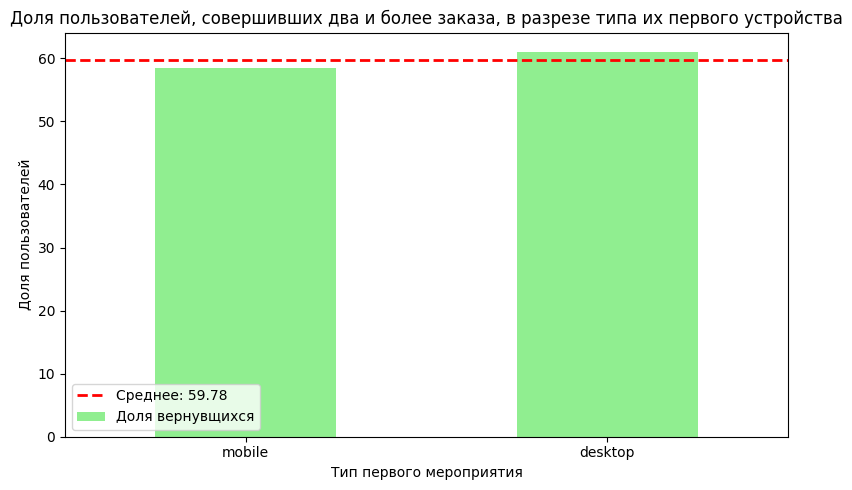

,first_device,count,return_rate_pct
1,mobile,17758,58.53
0,desktop,3670,61.04


In [43]:
# Доля пользователей совершивших два и более заказа в разрезе распределение пользователей по типу их первого устройства.
draft = (
    up.groupby('first_device')['is_two']
      .agg(['count', 'mean'])
      .rename(columns={'mean': 'return_rate_pct'})
      .reset_index()
)

# Приведем к процентному виду
draft['return_rate_pct'] = round((draft['return_rate_pct'] * 100), 2) 
# Выполним сортировку по долям
draft = draft.sort_values(by='return_rate_pct')
# Общее среднее только по доле, а не по всей таблице
avg = draft['return_rate_pct'].mean()

# Строим график
ax = draft.plot(
    kind='bar',
    x='first_device',
    y='return_rate_pct',
    title='Доля пользователей, совершивших два и более заказа, в разрезе типа их первого устройства',
    xlabel='Тип первого мероприятия',
    ylabel='Доля пользователей',
    figsize=(8, 5),
    rot=0,
    color='lightgreen',
    label='Доля вернувщихся'
)
# Добавим горизонтальную линию, символизирующую среднее значение
ax.axhline(
    avg,
    color='red',
    linestyle='--',
    linewidth=2,
    label=f'Среднее: {avg:.2f}'
)
plt.legend()
plt.tight_layout()
plt.show()

# Выводим числовые показатели
draft

**Комментарий:**
Заметим, что сегментов всего два, и разница в долях минимальна, из чего можем сделать вывод о том, что тип устройства не влияет на возвраты.

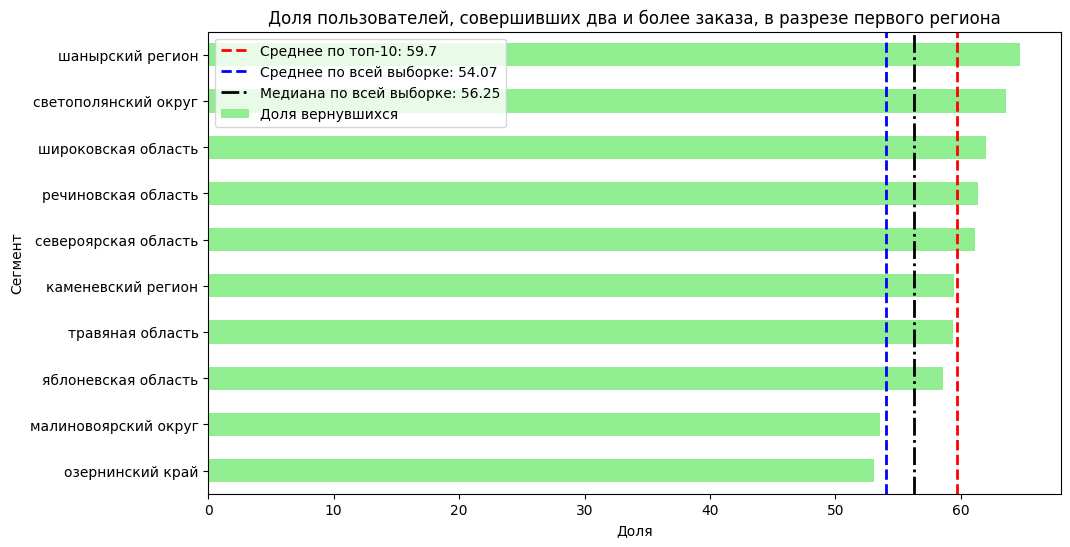

,first_region,count,return_rate_pct
0,шанырский регион,502,64.74
1,светополянский округ,456,63.60
2,широковская область,1211,62.01
3,речиновская область,435,61.38
4,североярская область,3720,61.13
5,каменевский регион,7038,59.45
6,травяная область,483,59.42
7,яблоневская область,406,58.62
8,малиновоярский округ,521,53.55
9,озернинский край,671,53.06


In [44]:
# Доля пользователей совершивших два и более заказа в разрезе распределение пользователей по региону проведения их первого мероприятия
# Считаем непосредственно долю пользователей (2+ заказа), так как поле is_two представленно (0,1) можно найти долю как среднее
draft = up.groupby(['first_region'])['is_two'].agg(['count', 'mean'])
draft = draft.rename(columns={'mean': 'return_rate_pct'})

# Приведем к процентному виду
draft['return_rate_pct'] = round((draft['return_rate_pct'] * 100), 2) 

# Глобально считаем среднее и медиану
avg_all = draft['return_rate_pct'].mean()
median_all = draft['return_rate_pct'].median()

# Отбираем топ-10 сегментов по количеству пользователей 
draft = draft.sort_values(by='count', ascending=False).head(10)
draft = draft.reset_index()

# Находим среднее по топу
avg = draft['return_rate_pct'].mean()

# Строим график и сохраняем ось в ax
ax = draft.sort_values(by='return_rate_pct').plot(
    kind='barh',
    title='Доля пользователей, совершивших два и более заказа, в разрезе первого региона',
    x='first_region', 
    y='return_rate_pct',
    xlabel='Доля',
    ylabel='Сегмент',
    label='Доля вернувшихся',
    figsize=(11, 6), 
    color='lightgreen'
)
# Добавим горизонтальную линию, символизирующую среднее значение по топу
ax.axvline(
    avg,
    color='red',
    linestyle='--',
    linewidth=2,
    label=f'Среднее по топ-10: {round(avg, 2)}'
)
# Добавим горизонтальную линию, символизирующую среднее значение по всей выборке
ax.axvline(
    avg_all,
    color='blue',
    linestyle='--',
    linewidth=2,
    label=f'Среднее по всей выборке: {round(avg_all, 2)}'
)
# Добавим горизонтальную линию, символизирующую медиану по всей выборке
ax.axvline(
    median_all,
    color='k',
    linestyle='-.',
    linewidth=2,
    label=f'Медиана по всей выборке: {round(median_all, 2)}'
)
plt.legend()
plt.show()

# Выводим числовые показатели в отсортированном виде
draft.sort_values(by='return_rate_pct', ascending=False).reset_index(drop=True)

**Комментарий:**
"Успешными точками входа" можем считать топ-8 представленных сегментов: у них высокие показатели доли возврата относительно всей выборки. Выделяются "наиболее успешные точки входа": "Шанырский регион" (**64.74%**), "Светополянский округ" (**63.6%**), "Широковская область" (**62.02%**), "Речиновская область" (**61.38%**), "Североярская область" (**61.13%**).

Отдельно выделим сегменты с наибольшим количеством клиентов — "Североярская область" (**3720**) и "Каменевский регион" (**7038**): их показатели доли возврата входят в топ-6.

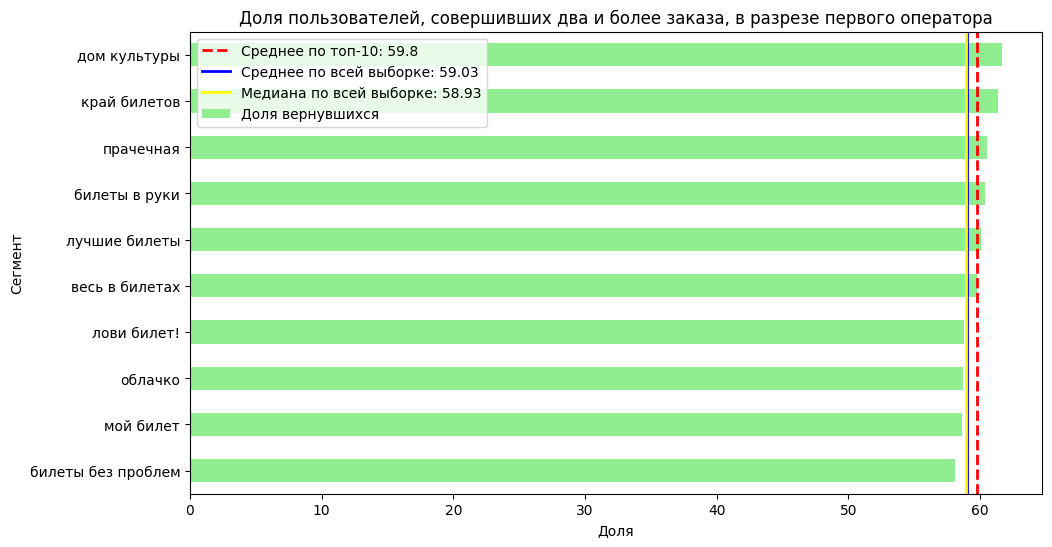

,first_service_name,count,return_rate_pct
9,дом культуры,352,61.65
8,край билетов,450,61.33
7,прачечная,578,60.55
3,билеты в руки,2532,60.39
6,лучшие билеты,1175,60.09
5,весь в билетах,1272,59.75
2,лови билет!,2785,58.78
4,облачко,2164,58.69
1,мой билет,2950,58.64
0,билеты без проблем,5108,58.10


In [45]:
# Доля пользователей совершивших два и более заказа в разрезе распределение пользователей по первому оператору
# Считаем непосредственно долю пользователей (2+ заказа), так как поле is_two представленно (0,1) можно найти долю как среднее
draft = up.groupby(['first_service_name'])['is_two'].agg(['count', 'mean'])
draft = draft.rename(columns={'mean': 'return_rate_pct'})

# Приведем к процентному виду
draft['return_rate_pct'] = round((draft['return_rate_pct'] * 100), 2) 

# Глобально считаем среднее и медиану
avg_all = draft['return_rate_pct'].mean()
median_all = draft['return_rate_pct'].median()

# Отбираем топ-10 сегментов по количеству пользователей
draft = draft.sort_values(by='count', ascending=False).head(10)
draft = draft.reset_index()

# Находим среднее по топу
avg = draft['return_rate_pct'].mean()

# Строим график и сохраняем ось в ax
ax = draft.sort_values(by='return_rate_pct').plot(
    kind='barh',
    title='Доля пользователей, совершивших два и более заказа, в разрезе первого оператора',
    x='first_service_name', 
    y='return_rate_pct',
    xlabel='Доля',
    ylabel='Сегмент',
    label='Доля вернувшихся',
    figsize=(11, 6), 
    color='lightgreen'
)
# Добавим горизонтальную линию, символизирующую среднее значение по топу
ax.axvline(
    avg,
    color='red',
    linestyle='--',
    linewidth=2,
    label=f'Среднее по топ-10: {round(avg, 2)}'
)
# Добавим горизонтальную линию, символизирующую среднее значение по всей выборке
ax.axvline(
    avg_all,
    color='blue',
    linestyle='-',
    linewidth=2,
    label=f'Среднее по всей выборке: {round(avg_all, 2)}'
)
# Добавим горизонтальную линию, символизирующую медиану по всей выборке
ax.axvline(
    median_all,
    color='yellow',
    linestyle='-',
    linewidth=2,
    label=f'Медиана по всей выборке: {round(median_all, 2)}'
)
plt.legend()
plt.show()

# Выводим числовые показатели в отсортированном виде
draft.sort_values(by='return_rate_pct', ascending=False)

**Комментарий:**
"Дом культуры" (**61.65%**) и "Край билетов" (**61.33%**) демонстрируют наибольшую долю возвратов, однако разница с другими сегментами незначительна. Это позволяет сделать вывод о том, что выбор билетного оператора не оказывает существенного влияния на возвраты. 

**Промежуточный вывод:**

Мы проанализировали влияние различных факторов на вероятность возврата пользователей и можем сделать следующие обобщения.

Мы видим, что тип устройства ("mobile" — **58.53%**, "desktop" — **61.04%**) не оказывает значимого влияния на возвраты, так как разница между сегментами минимальна.

Мы также рассмотрели распределение по регионам и выявили, что "успешными точками входа" можно считать топ-8 сегментов, где доля возврата выше среднего по выборке. Особенно выделяются "Шанырский регион" (**64.74%**), "Светополянский округ" (**63.6%**), "Широковская область" (**62.02%**), "Речиновская область" (**61.38%**) и "Североярская область" (**61.13%**). При этом мы учли, что наибольшее количество пользователей сосредоточено в "Североярская область" (**3720**) и "Каменевский регион" (**7038**), однако их показатели возврата находятся на среднем уровне. Это позволяет сделать вывод, что регион влияет на объем привлечения пользователей, но не оказывает значимого влияния на их склонность к повторным заказам.

Мы проанализировали влияние первого билетного оператора и установили, что несмотря на то, что "Дом культуры" (**61.65%**) и "Край билетов" (**61.33%**) демонстрируют наибольшие значения, различия между сегментами несущественны. Это позволяет сделать вывод о том, что выбор оператора не влияет на вероятность возврата пользователей.

Таким образом, мы можем сделать общий вывод: ни тип устройства, ни регион, ни первый оператор не оказывают значимого влияния на вероятность возврата пользователей, а наблюдаемые различия между сегментами находятся в сопоставимых пределах.

#### 7.1.3. Опираясь на выводы из задач выше, проверим продуктовые гипотезы:

**Гипотеза 1.** Тип мероприятия влияет на вероятность возврата на Яндекс Афишу: пользователи, совершившие первый заказ на спортивные мероприятия, возвращаются чаще, чем пользователи, оформившие первый заказ на концерты.

Данное утверждение не подтверждается — наблюдается скорее обратная зависимость. Тип мероприятия действительно влияет на вероятность возврата, однако степень этого влияния требует дополнительной оценки. По данным видно, что на **4%** больше пользователей возвращаются после "концерта", чем после "спортивного мероприятия".

**Гипотеза 2.** В регионах с наибольшей активностью пользователей доля повторных заказов выше, чем в менее активных регионах.

Если измерять активность региона по количеству зарегистрированных пользователей, указавших данный регион, гипотеза не подтверждается. При этом можно отметить следующее: большинство пользователей сосредоточено в двух регионах — "Каменевский регион" (**7038**) и "Североярская область" (**3720**). Это составляет около **2/3** от топа и примерно **1/2** от всей выборки.

Судя по данным, показатели доли возврата в этих регионах находятся на среднем уровне. В регионах, где наблюдаются отклонения (относительно топа), количество пользователей значительно меньше, что снижает доверие к этим значениям. При этом различия в долях возврата не выглядят аномальными и находятся в сопоставимых пределах.

Таким образом, можно сделать вывод, что регион влияет на количество привлечённых пользователей, но не оказывает значимого влияния на их мотивацию к повторному заказу.